In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.metrics import adjusted_rand_score
from matplotlib.colors import ListedColormap

import sys
import os
sys.path.append(os.path.abspath('../utils'))
from ClusterAlgorithms import ClusterBy
from ClusterAlgorithms import k_LE_SC

In [2]:
from scipy.sparse import load_npz
# Load adjacency matrix
Ad = load_npz("adjacency.npz")
# Load labels
y_true = np.load("labels.npy")

In [3]:
# randomly permutate the input data
N = Ad.shape[0]
permutation = np.random.permutation(N)
Ad = Ad[permutation, :][:, permutation]
y_true = y_true[permutation]


In [4]:

# Number of clusters
k = 3
# Number of repetitions
num_rep = 5
GCluster = ClusterBy(Ad, k)

y_Herm_best = np.zeros((1, N))
y_Sym_best = np.zeros((1, N))
y_BibSym_best = np.zeros((1, N))
y_DISIM_L_best = np.zeros((1, N))
y_DISIM_R_best = np.zeros((1, N))
y_DSCORE_best = np.zeros((1, N))
y_SimpHerm_best = np.zeros((1, N))
y_LESC_best = np.zeros((1, N))


ARI_Herm = np.zeros(num_rep)
ARI_Sym = np.zeros(num_rep)
ARI_BibSym = np.zeros(num_rep)
ARI_DISIM_L = np.zeros(num_rep)
ARI_DISIM_R = np.zeros(num_rep)
ARI_DSCORE = np.zeros(num_rep)
ARI_SimpHerm = np.zeros(num_rep)
ARI_LESC = np.zeros(num_rep)


for i in range(num_rep):

  y_Herm = GCluster.HermCLuster()
  y_Sym = GCluster.SpectralCluster()
  y_BibSym = GCluster.BibSym()
  y_DISIM_L, y_DISIM_R = GCluster.DISIM(reg=1)
  y_DSCORE = GCluster.DSCORE()
  y_SimpHerm = GCluster.SimpHerm()

  # Our method: iterative LE-SC iterative
  y_LESC = k_LE_SC(Ad, k, max_iter=10, init='Herm', t=0.01)

  ARI_Herm[i]= adjusted_rand_score(y_true, y_Herm)
  ARI_Sym[i] = adjusted_rand_score(y_true, y_Sym)
  ARI_BibSym[i] = adjusted_rand_score(y_true, y_BibSym)
  ARI_DISIM_L[i] = adjusted_rand_score(y_true, y_DISIM_L)
  ARI_DISIM_R[i] = adjusted_rand_score(y_true, y_DISIM_R)
  ARI_DSCORE[i] = adjusted_rand_score(y_true, y_DSCORE)
  ARI_SimpHerm[i] = adjusted_rand_score(y_true, y_SimpHerm)
  ARI_LESC[i] = adjusted_rand_score(y_true, y_LESC)

  if ARI_Herm[i] == np.max(ARI_Herm):
    y_Herm_best = y_Herm
  if ARI_Sym[i] == np.max(ARI_Sym):
    y_Sym_best = y_Sym
  if ARI_BibSym[i] == np.max(ARI_BibSym):
    y_BibSym_best = y_BibSym
  if ARI_DISIM_L[i] == np.max(ARI_DISIM_L):
    y_DISIM_L_best = y_DISIM_L
  if ARI_DISIM_R[i] == np.max(ARI_DISIM_R):
    y_DISIM_R_best = y_DISIM_R
  if ARI_DSCORE[i] == np.max(ARI_DSCORE):
    y_DSCORE_best = y_DSCORE
  if ARI_SimpHerm[i] == np.max(ARI_SimpHerm):
    y_SimpHerm_best = y_SimpHerm
  if ARI_LESC[i] == np.max(ARI_LESC):
    y_LESC_best = y_LESC

Iterative LE-SC converged within 2 iterations.
Iterative LE-SC converged within 6 iterations.
Iterative LE-SC converged within 2 iterations.
Iterative LE-SC converged within 6 iterations.
Iterative LE-SC converged within 2 iterations.
Iterative LE-SC converged within 6 iterations.
Iterative LE-SC converged within 2 iterations.
Iterative LE-SC converged within 6 iterations.
Iterative LE-SC converged within 2 iterations.
Iterative LE-SC converged within 6 iterations.


In [5]:
results = {
    'Algorithm': ['Herm', 'Sym', 'BibSym',
                  'DISIM_L', 'DISIM_R', 'DSCORE',
                  'SimpHerm', 'LE-SC'],
    'ARI': [np.mean(ARI_Herm), np.mean(ARI_Sym), np.mean(ARI_BibSym),
             np.mean(ARI_DISIM_L), np.mean(ARI_DISIM_R), np.mean(ARI_DSCORE),
             np.mean(ARI_SimpHerm), np.mean(ARI_LESC)],
    'std': [np.std(ARI_Herm), np.std(ARI_Sym), np.std(ARI_BibSym),
             np.std(ARI_DISIM_L), np.std(ARI_DISIM_R), np.std(ARI_DSCORE),
             np.std(ARI_SimpHerm), np.std(ARI_LESC)]
}

df = pd.DataFrame(results)
print(df)


  Algorithm       ARI       std
0      Herm  0.456031  0.000000
1       Sym  0.394443  0.000000
2    BibSym  0.315331  0.000000
3   DISIM_L  0.321200  0.000000
4   DISIM_R  0.386886  0.000000
5    DSCORE  0.035192  0.009859
6  SimpHerm  0.065833  0.146462
7     LE-SC  0.499699  0.000000


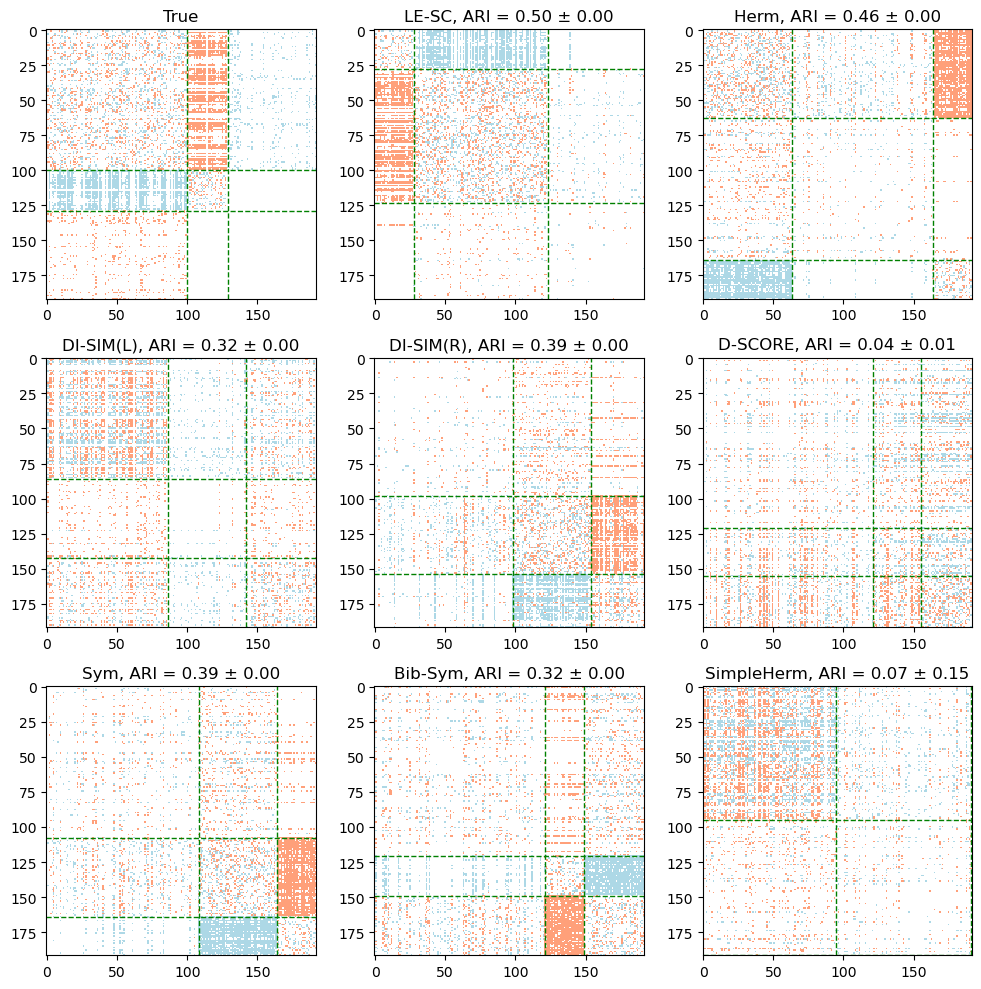

In [6]:
light_red = '#FFA07A'  # Light Salmon color 
light_blue = '#ADD8E6' # Light Blue color
cmap = ListedColormap([light_blue, 'white', light_red])

def reorder_by_cluster(adjacency_matrix, cluster_labels):
    """Reorders the adjacency matrix based on cluster labels."""

    # Assuming cluster labels are indices starting from 0
    N = adjacency_matrix.shape[0]
    reordered_indices = np.argsort(cluster_labels)
    reordered_matrix = adjacency_matrix[reordered_indices, :][:, reordered_indices]

    return reordered_matrix


def plot_reordered_adjacency(adjacency_matrix, cluster_labels, title):
    """Plots a reordered adjacency matrix with cluster boundaries."""

    reordered_adjacency = reorder_by_cluster(adjacency_matrix, cluster_labels)

    plt.imshow(reordered_adjacency.todense() - reordered_adjacency.todense().T,
               interpolation='none', cmap=cmap, vmin=-1, vmax=1)
    plt.title(title)

    # Find cluster boundaries (indices where cluster labels change)
    boundaries = np.where(np.diff(cluster_labels[np.argsort(cluster_labels)]) != 0)[0] + 1

    # Plot the boundaries
    for boundary in boundaries:
        plt.axvline(x=boundary, color='green', linestyle='--', linewidth = 1)  # Vertical lines
        plt.axhline(y=boundary, color='green', linestyle='--',linewidth = 1)  # Horizontal lines

# Example usage (assuming you have Ad, y_hat, cmap defined)
plt.figure(figsize=(10, 10))

plt.subplot(3,3,1)
plot_reordered_adjacency(Ad, y_true, f"True")

plt.subplot(3,3,2)
plot_reordered_adjacency(Ad, y_LESC_best, f"LE-SC, ARI = {np.mean(ARI_LESC):.2f} ± {np.std(ARI_LESC):.2f}")

plt.subplot(3,3,3)
plot_reordered_adjacency(Ad, y_Herm_best, f"Herm, ARI = {np.mean(ARI_Herm):.2f} ± {np.std(ARI_Herm):.2f}")

plt.subplot(3,3,4)
plot_reordered_adjacency(Ad, y_DISIM_L_best, f"DI-SIM(L), ARI = {np.mean(ARI_DISIM_L):.2f} ± {np.std(ARI_DISIM_L):.2f}")

plt.subplot(3,3,5)
plot_reordered_adjacency(Ad, y_DISIM_R_best, f"DI-SIM(R), ARI = {np.mean(ARI_DISIM_R):.2f} ± {np.std(ARI_DISIM_R):.2f}")

plt.subplot(3,3,6)
plot_reordered_adjacency(Ad, y_DSCORE_best, f"D-SCORE, ARI = {np.mean(ARI_DSCORE):.2f} ± {np.std(ARI_DSCORE):.2f}")

plt.subplot(3,3,7)
plot_reordered_adjacency(Ad, y_Sym_best, f"Sym, ARI = {np.mean(ARI_Sym):.2f} ± {np.std(ARI_Sym):.2f}")

plt.subplot(3,3,8)
plot_reordered_adjacency(Ad, y_BibSym_best, f"Bib-Sym, ARI = {np.mean(ARI_BibSym):.2f} ± {np.std(ARI_BibSym):.2f}")

plt.subplot(3,3,9)
plot_reordered_adjacency(Ad, y_SimpHerm_best, f"SimpleHerm, ARI = {np.mean(ARI_SimpHerm):.2f} ± {np.std(ARI_SimpHerm):.2f}")

plt.tight_layout()
# plt.show()

